In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay

In [2]:
data = pd.read_csv('ai_dev_productivity.csv')
data.head()

,hours_coding,coffee_intake_mg,distractions,sleep_hours,commits,bugs_reported,ai_usage_hours,cognitive_load,task_success
0,5.99,600,1,5.8,2,1,0.71,5.4,1
1,4.72,568,2,6.9,5,3,1.75,4.7,1
2,6.30,560,1,8.9,2,0,2.27,2.2,1
3,8.05,600,7,6.3,9,5,1.40,5.9,0
4,4.53,421,6,6.9,4,0,1.26,6.3,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hours_coding      500 non-null    float64
 1   coffee_intake_mg  500 non-null    int64  
 2   distractions      500 non-null    int64  
 3   sleep_hours       500 non-null    float64
 4   commits           500 non-null    int64  
 5   bugs_reported     500 non-null    int64  
 6   ai_usage_hours    500 non-null    float64
 7   cognitive_load    500 non-null    float64
 8   task_success      500 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


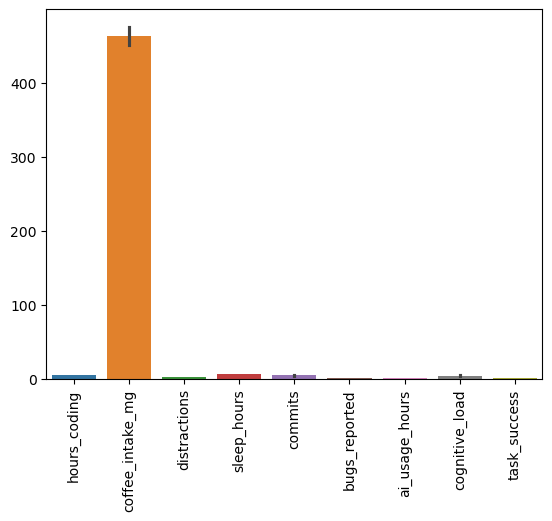

In [4]:
sns.barplot(data=data)
plt.xticks(rotation=90)
plt.show()

In [5]:
data['coffee_intake_mg'].value_counts()

coffee_intake_mg
600    145
494      6
514      5
414      4
473      4
      ... 
564      1
340      1
468      1
558      1
296      1
Name: count, Length: 244, dtype: int64

In [6]:
X = data.drop(['task_success'],axis=1)
y = data['task_success']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [11]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [14]:
# Define models and parameters
model = {
    'LogisticRegression': {
        'model': LogisticRegression(),
        'param_grid': {
            'max_iter': [100,200]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'param_grid': {
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(),
        'param_grid': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5, 10]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(objective='reg:squarederror', random_state=42),
        'param_grid': {
            'n_estimators': [50, 100],
            'max_depth': [3, 5],
            'learning_rate': [0.01, 0.1]
        }
    },
    'SVM': {
        'model': SVC(probability=True),
        'param_grid': {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'param_grid': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        }
    }
}

# Testing Data Scores

In [15]:
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Run GridSearchCV for each model
results = []

for name, mp in model.items():
    grid = GridSearchCV(mp['model'], param_grid=mp['param_grid'], cv=3, scoring='accuracy')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    clf_report = classification_report(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'F1 Score': f1,
        'Accuracy Score': acc,
        'Classification Report': clf_report
    })

# Output results
results_df = pd.DataFrame(results)
print("\nSummary Results:")
print(results_df[['Model', 'Best Params', 'F1 Score', 'Accuracy Score']])


Summary Results:
                Model                                        Best Params  \
0  LogisticRegression                                  {'max_iter': 100}   
1       Decision Tree           {'max_depth': 3, 'min_samples_split': 2}   
2       Random Forest              {'max_depth': 5, 'n_estimators': 100}   
3             XGBoost  {'learning_rate': 0.01, 'max_depth': 3, 'n_est...   
4                 SVM                     {'C': 0.1, 'kernel': 'linear'}   
5                 KNN          {'n_neighbors': 7, 'weights': 'distance'}   

   F1 Score  Accuracy Score  
0  0.920000            0.92  
1  1.000000            1.00  
2  1.000000            1.00  
3  1.000000            1.00  
4  0.909823            0.91  
5  0.908907            0.91  


# Training Data Scores

In [16]:
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Run GridSearchCV for each model
results = []

for name, mp in model.items():
    grid = GridSearchCV(mp['model'], param_grid=mp['param_grid'], cv=3, scoring='accuracy')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_train_pred = best_model.predict(X_train)

    clf_report = classification_report(y_train, y_train_pred)
    f1 = f1_score(y_train, y_train_pred, average='weighted')
    acc = accuracy_score(y_train, y_train_pred)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'F1 Score': f1,
        'Accuracy Score': acc,
        'Classification Report': clf_report
    })

# Output results
results_df = pd.DataFrame(results)
print("\nSummary Results:")
print(results_df[['Model', 'Best Params', 'F1 Score', 'Accuracy Score']])


Summary Results:
                Model                                        Best Params  \
0  LogisticRegression                                  {'max_iter': 100}   
1       Decision Tree           {'max_depth': 3, 'min_samples_split': 2}   
2       Random Forest              {'max_depth': 10, 'n_estimators': 50}   
3             XGBoost  {'learning_rate': 0.01, 'max_depth': 3, 'n_est...   
4                 SVM                     {'C': 0.1, 'kernel': 'linear'}   
5                 KNN          {'n_neighbors': 7, 'weights': 'distance'}   

   F1 Score  Accuracy Score  
0  0.864312          0.8650  
1  1.000000          1.0000  
2  1.000000          1.0000  
3  0.997499          0.9975  
4  0.881648          0.8825  
5  1.000000          1.0000  


In [17]:
feature_columns = X.columns.to_list()
joblib.dump(feature_columns,'features_ai_dev_productivity.joblib')

['features_ai_dev_productivity.joblib']

In [18]:
joblib.dump(best_model,'best_model_ai_dev_productivity.joblib')

['best_model_ai_dev_productivity.joblib']

In [ ]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('best_model_ai_dev_productivity.joblib')
features = joblib.load('features_ai_dev_productivity.joblib')
st.title('AI_Dev_Productivity')

user_input={}
for i in features:
    user_input[i] = st.number_input(i,value=0.0)

if st.button('Predict'):
    data = pd.DataFrame([user_input])
    pred = model.predict(data)[0]
    st.success(f'Prediction : {(pred)}')

In [ ]:
cd .venv
streamlit run filename.py